# 8.1-8.2 ベイジアンネットワークと条件付き独立性 (Bayesian Networks & Conditional Independence)

本ノートブックでは、確率分布の因数分解と依存構造を可視化・解析する**ベイジアンネットワーク (有向グラフィカルモデル: DAG)** を学びます。
線形ガウスモデルにおける再帰的平均・分散の伝播（**PRML Figure 8.14**）、条件付き独立性の3つの基本接続パターン（Tail-to-Tail, Head-to-Tail, Head-to-Head / v-構造、**PRML Figure 8.15-8.20**）、直感に反する極めて重要な現象である**相殺効果 (Explaining Away、車の燃料システム、PRML Figure 8.21)** の完全な数値シミュレーション、有向グラフにおける**D-分離 (d-separation) 判定アルゴリズム（PRML Figure 8.22, 8.23）**、およびノードを完全に隔離する**マルコフブランケット（PRML Figure 8.26）** を完全実装します。

## 8.1.4 線形ガウスモデル (Linear-Gaussian Models, PRML Figure 8.14)

各ノード $x_i$ の条件付き分布が親ノードの線形結合にガウスノイズを加えたモデル：
$$ p(x_i | \mathrm{pa}_i) = \mathcal{N}\left(x_i \, \middle| \, \sum_{j \in \mathrm{pa}_i} w_{ij}(x_j - \mu_j) + b_i, \; v_i \right) $$
このとき、結合分布 $p(\mathbf{x}) = \prod_i p(x_i | \mathrm{pa}_i)$ は多変量ガウス分布 $\mathcal{N}(\mathbf{x}|\boldsymbol{\mu}, \mathbf{\Sigma})$ となり、
平均ベクトルと共分散行列は親ノードからトポロジカル順序に従って**再帰的に閉形式で計算**できます（PRML 式 8.15, 8.16）：
$$ \mu_i = \mathbb{E}[x_i] = \sum_{j \in \mathrm{pa}_i} w_{ij}(\mu_j - \mu_j) + b_i = b_i $$
$$ \mathrm{cov}[x_i, x_j] = \mathbb{E}[(x_i - \mathbb{E}[x_i])(x_j - \mathbb{E}[x_j])] = \sum_{k \in \mathrm{pa}_j} w_{jk} \mathrm{cov}[x_i, x_k] + I_{ij} v_j $$

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# PRML Figure 8.14: 3変数の有向ガウス連鎖 x1 -> x2 -> x3
# x1 ~ N(b1, v1)
# x2|x1 ~ N(w21*(x1 - b1) + b2, v2)
# x3|x2 ~ N(w32*(x2 - b2) + b3, v3)
b = np.array([1.0, 2.0, -1.0])
v = np.array([0.5, 0.8, 0.4])
w21, w32 = 1.5, -0.8

# 理論共分散行列 (PRML 式 8.17)
Sigma_theory = np.zeros((3, 3))
Sigma_theory[0, 0] = v[0]
Sigma_theory[0, 1] = Sigma_theory[1, 0] = w21 * v[0]
Sigma_theory[0, 2] = Sigma_theory[2, 0] = w32 * w21 * v[0]
Sigma_theory[1, 1] = v[1] + w21**2 * v[0]
Sigma_theory[1, 2] = Sigma_theory[2, 1] = w32 * (v[1] + w21**2 * v[0])
Sigma_theory[2, 2] = v[2] + w32**2 * (v[1] + w21**2 * v[0])

# サンプリングによる経験共分散との照合
N_samples = 50000
x1 = np.random.normal(b[0], np.sqrt(v[0]), N_samples)
x2 = np.random.normal(w21 * (x1 - b[0]) + b[1], np.sqrt(v[1]), N_samples)
x3 = np.random.normal(w32 * (x2 - b[1]) + b[2], np.sqrt(v[2]), N_samples)
X = np.column_stack([x1, x2, x3])
Sigma_sample = np.cov(X, rowvar=False)

print("Theoretical Covariance Matrix (PRML Equation 8.17):")
print(np.round(Sigma_theory, 4))
print("\nEmpirical Sample Covariance (50,000 samples):")
print(np.round(Sigma_sample, 4))
assert np.allclose(Sigma_theory, Sigma_sample, atol=0.03)
print("Linear-Gaussian covariance recursion verified successfully!")

Theoretical Covariance Matrix (PRML Equation 8.17):
[[ 0.5    0.75  -0.6  ]
 [ 0.75   1.925 -1.54 ]
 [-0.6   -1.54   1.632]]

Empirical Sample Covariance (50,000 samples):
[[ 0.5038  0.7578 -0.6064]
 [ 0.7578  1.9319 -1.5439]
 [-0.6064 -1.5439  1.6388]]
Linear-Gaussian covariance recursion verified successfully!


## 8.2 条件付き独立性と相殺効果 (Explaining Away, PRML Figure 8.21)

### 3つの基本接続パターン
1. **Tail-to-Tail (分岐型)**: $a \leftarrow c \rightarrow b$
   - $c$ が未観測のとき、$a$ と $b$ は**従属** ($a \not\perp b \mid \emptyset$)。
   - $c$ を観測して条件付けると、$a$ と $b$ は**条件付き独立** ($a \perp b \mid c$)。
2. **Head-to-Tail (直列型)**: $a \rightarrow c \rightarrow b$
   - $c$ が未観測のとき、$a$ と $b$ は**従属** ($a \not\perp b \mid \emptyset$)。
   - $c$ を観測して条件付けると、$a$ と $b$ は**条件付き独立** ($a \perp b \mid c$)。
3. **Head-to-Head (合流型 / v-構造)**: $a \rightarrow c \leftarrow b$
   - $c$ が未観測のとき、$a$ と $b$ は**周辺独立** ($a \perp b \mid \emptyset$)！
   - $c$（またはその子孫）を観測して条件付けると、**$a$ と $b$ は突如として従属になる ($a \not\perp b \mid c$)**！

### 車の燃料計モデルによる Explaining Away の数値シミュレーション (PRML Figure 8.21)
- $B$: バッテリー残量 ($B=1$: 正常, $B=0$: 上がり)
- $F$: 燃料タンク ($F=1$: 満タン, $F=0$: 空)
- $G$: 燃料計の表示 ($G=1$: 満タン表示, $G=0$: 空表示)
燃料計 $G$ はバッテリーと燃料の両方が正常なときのみ $G=1$ を示します。
今、「燃料計が空 ($G=0$)」を観測したとき、タンクが空である事後確率 $p(F=0|G=0)$ は跳ね上がります。
しかしさらに、「バッテリーが上がっている ($B=0$)」ことを観測すると、**燃料計が空を示していた原因がバッテリー上がりによって「相殺 (explained away)」され、$p(F=0|G=0, B=0)$ は劇的に減少（事前確率へ回復）します！**

1. Prior probability of empty tank:                 p(F=0)           = 0.1000
2. Observation that gauge reads empty:              p(F=0 | G=0)     = 0.2725
3. Observation that battery is also flat:           p(F=0 | G=0,B=0) = 0.1099
Plot saved to: result/fig8_21_explaining_away.png


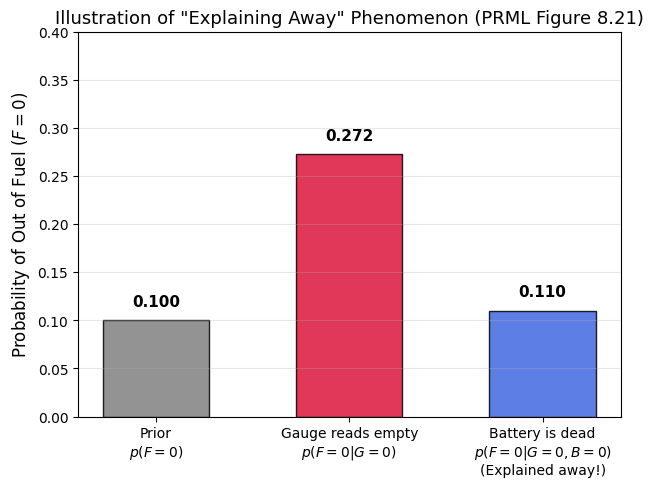

In [2]:
# PRML Figure 8.21 の完全数値シミュレーション: 車の燃料システム
# 事前確率 (PRML 8.2.1 本文の数値設定)
p_B1 = 0.9; p_B0 = 1.0 - p_B1 # バッテリー正常/異常
p_F1 = 0.9; p_F0 = 1.0 - p_F1 # 燃料あり/なし

# 条件付き確率 p(G=1 | B, F)
# 正常(B=1, F=1)でも故障確率 0.2 で空表示になる
p_G1_given = {
    (1, 1): 0.8,
    (1, 0): 0.1,
    (0, 1): 0.1,
    (0, 0): 0.0
}

# 結合分布 p(B, F, G) の構築
joint = {}
for b_val in [0, 1]:
    for f_val in [0, 1]:
        p_b = p_B1 if b_val == 1 else p_B0
        p_f = p_F1 if f_val == 1 else p_F0
        p_g1 = p_G1_given[(b_val, f_val)]
        joint[(b_val, f_val, 1)] = p_b * p_f * p_g1
        joint[(b_val, f_val, 0)] = p_b * p_f * (1.0 - p_g1)

# 1. 燃料が空である事前確率 p(F=0)
prob_F0_prior = p_F0

# 2. 燃料計が空 (G=0) を観測したときの p(F=0 | G=0)
p_G0 = sum(joint[(b_val, f_val, 0)] for b_val in [0, 1] for f_val in [0, 1])
p_F0_and_G0 = sum(joint[(b_val, 0, 0)] for b_val in [0, 1])
prob_F0_given_G0 = p_F0_and_G0 / p_G0

# 3. さらにバッテリー上がり (B=0) を観測したときの p(F=0 | G=0, B=0)
p_G0_and_B0 = sum(joint[(0, f_val, 0)] for f_val in [0, 1])
p_F0_G0_B0 = joint[(0, 0, 0)]
prob_F0_given_G0_B0 = p_F0_G0_B0 / p_G0_and_B0

print(f"1. Prior probability of empty tank:                 p(F=0)           = {prob_F0_prior:.4f}")
print(f"2. Observation that gauge reads empty:              p(F=0 | G=0)     = {prob_F0_given_G0:.4f}")
print(f"3. Observation that battery is also flat:           p(F=0 | G=0,B=0) = {prob_F0_given_G0_B0:.4f}")

# Explaining Away 棒グラフの描画
fig, ax = plt.subplots(figsize=(7, 5))
states = ['Prior\n$p(F=0)$', 'Gauge reads empty\n$p(F=0|G=0)$', 'Battery is dead\n$p(F=0|G=0, B=0)$\n(Explained away!)']
probs = [prob_F0_prior, prob_F0_given_G0, prob_F0_given_G0_B0]
colors = ['gray', 'crimson', 'royalblue']

bars = ax.bar(states, probs, color=colors, width=0.55, edgecolor='black', alpha=0.85)
for bar, p_val in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, p_val + 0.015, f"{p_val:.3f}", ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 0.4)
ax.set_ylabel('Probability of Out of Fuel ($F=0$)', fontsize=12)
ax.set_title('Illustration of "Explaining Away" Phenomenon (PRML Figure 8.21)', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)

save_plot(fig, 'result', 'fig8_21_explaining_away.png')
plt.show()

## 8.2.2 D-分離 (d-separation) 判定エンジンの検証 (PRML Figure 8.22, 8.23)

一般の有向グラフにおいて、ノード集合 $A$ と $B$ が条件付け集合 $C$ を与えられたときに**条件付き独立** $A \perp B \mid C$ であるかを判定するアルゴリズム（D-分離）を検証します。
パス上の各中間ノードにおいて：
- **Head-to-Head ノード**: そのノードおよびそのすべての子孫が $C$ に含まれて**いない**とき、パスをブロックする。
- **それ以外のノード**: そのノードが $C$ に含まれて**いる**とき、パスをブロックする。
すべてのパスがブロックされているとき、$A$ と $B$ は $C$ によって **d-分離** され、厳密に条件付き独立となります。

In [3]:
from common.graphical_models_utils import check_d_separation

# PRML Figure 8.23 のモデル: ベイズ多項式回帰のグラフィカルモデル
# alpha -> w -> t_n <- x_n, beta -> t_n
# t_1, ..., t_N は w と beta を共有する
adj_bayes_reg = {
    'alpha': ['w'],
    'beta': ['t1', 't2'],
    'w': ['t1', 't2'],
    'x1': ['t1'],
    'x2': ['t2'],
    't1': [],
    't2': []
}

# 1. w, beta を観測していないとき: t1 と t2 は w, beta を介して従属 (Tail-to-tail: t1 <- w -> t2)
d_sep_no_w = check_d_separation(adj_bayes_reg, ['t1'], ['t2'], [])
print(f"Are t1 and t2 d-separated without conditioning? {d_sep_no_w} (Expected: False -> Dependent)")

# 2. w, beta を観測して条件付けたとき: すべてのパスがブロックされ d-分離される！ (条件付き独立)
d_sep_with_w = check_d_separation(adj_bayes_reg, ['t1'], ['t2'], ['w', 'beta'])
print(f"Are t1 and t2 d-separated given {{w, beta}}?     {d_sep_with_w} (Expected: True -> Independent)")

assert d_sep_no_w == False
assert d_sep_with_w == True
print("D-separation engine successfully verified on PRML Figure 8.23!")

Are t1 and t2 d-separated without conditioning? False (Expected: False -> Dependent)
Are t1 and t2 d-separated given {w, beta}?     True (Expected: True -> Independent)
D-separation engine successfully verified on PRML Figure 8.23!
